# 数据来自 1025_test_choose_degree2

Saved figure to ./rho_random.pdf


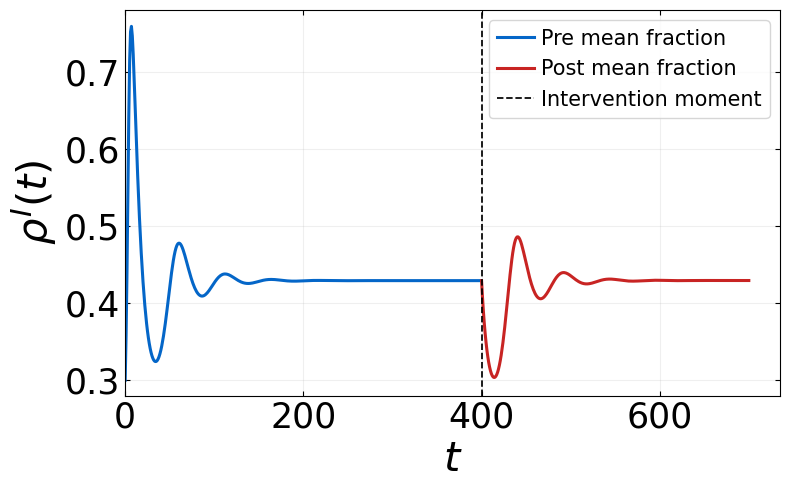

In [2]:
#!/usr/bin/env python3
# plot_stage_intervention_with_deg.py
"""
随机重连版本 - 绘图部分
绘制感染率时间序列和度分布图，包含免疫前后度分布对比直方图
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========== 配置 ==========
out_dir = "./runs_fixed_random"
plot_individual_runs = True
save_png = True

png_name_times = "rho_random.pdf"

png_name_deg_comparison = "histogram_random.pdf"

# ========== 读取数据 ==========
pre_file = os.path.join(out_dir, "pre_rho_all.csv")
post_file = os.path.join(out_dir, "post_rho_all.csv")

deg_summary_before_file = os.path.join(out_dir, "degree_hist_summary_before.csv")
deg_summary_after_file = os.path.join(out_dir, "degree_hist_summary_after.csv")

# 读取感染率数据
pre_rho_all = pd.read_csv(pre_file, header=None).to_numpy()
post_rho_all = pd.read_csv(post_file, header=None).to_numpy()


T_pre, R_pre = pre_rho_all.shape
T_post, R_post = post_rho_all.shape
R = min(R_pre, R_post)

if R_pre != R_post:
    pre_rho_all = pre_rho_all[:, :R]
    post_rho_all = post_rho_all[:, :R]

mean_pre = pre_rho_all.mean(axis=1)
std_pre  = pre_rho_all.std(axis=1)
mean_post = post_rho_all.mean(axis=1)
std_post  = post_rho_all.std(axis=1)

t_pre = np.arange(T_pre)
t_post = np.arange(T_post) + T_pre

# ---------- 时序图 ----------
plt.figure(figsize=(8,5))
plt.plot(t_pre, mean_pre, color='#0466c8', lw=2.2, label='Pre mean fraction')

plt.plot(t_post, mean_post, color='#c82423', lw=2.2, label='Post mean fraction')


intervention_t = T_pre
plt.axvline(intervention_t, color='k', linestyle='--', lw=1.25, label='Intervention moment')

plt.xlabel(r"$t$", fontsize=30)
plt.ylabel(r"$\rho^I(t)$", fontsize=30)
# plt.title("Comparison of pre and post stage infection rate (Random Rewiring)", fontsize=13, fontweight='bold')
plt.xlim(left=0)
ymin = max(0.0, min(np.min(mean_pre - std_pre), np.min(mean_post - std_post)) - 0.02)
ymax = min(1.0, max(np.max(mean_pre + std_pre), np.max(mean_post + std_post)) + 0.02)
plt.ylim(ymin, ymax)
plt.xticks(np.linspace(0,600,4),fontsize=25)
plt.yticks(fontsize=25)
plt.grid(alpha=0.2)
legend = plt.legend(
    loc='upper right',
    # bbox_to_anchor=(1, 0.55),
    fontsize='15',
    handletextpad=0.3,    # 图标与文本的间距
    handlelength=1.8,    # 统一图标宽度
)
# 启用四面刻度
plt.tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
)


plt.tight_layout()

if save_png:
    out_png = os.path.join("./", png_name_times)
    plt.savefig(out_png, dpi=300)
    print(f"Saved figure to {out_png}")
plt.show()



Saved degree distribution comparison histogram to ./histogram_random.pdf


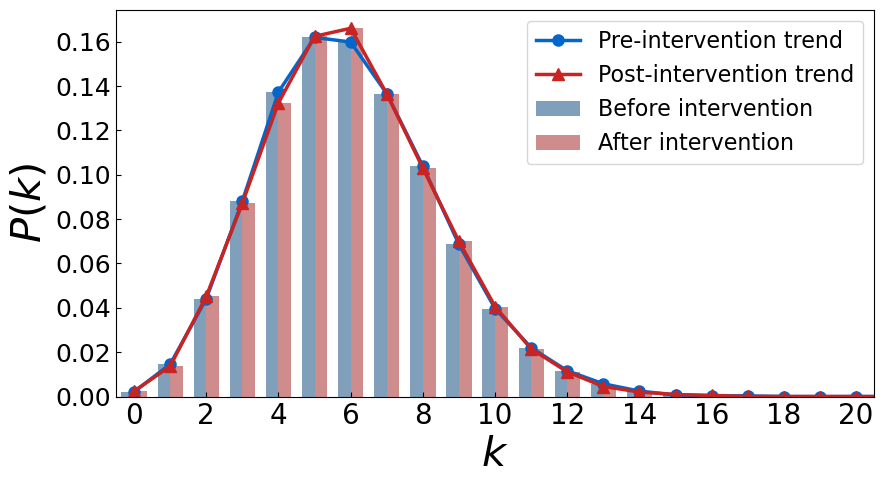

In [5]:
# ---------- 度分布对比直方图（在同一张图上）----------
if os.path.exists(deg_summary_before_file) and os.path.exists(deg_summary_after_file):
    deg_before = pd.read_csv(deg_summary_before_file)
    deg_after = pd.read_csv(deg_summary_after_file)
    
    # 为了更好的可视化，限制显示的度数范围
    max_deg_plot = 30  # 只显示0-30度的节点
    
    # 过滤数据
    deg_before_filtered = deg_before[deg_before['degree'] <= max_deg_plot]
    deg_after_filtered = deg_after[deg_after['degree'] <= max_deg_plot]
    
    # 创建完整的度数范围（从0到max_deg_plot）
    all_degrees = np.arange(0, max_deg_plot + 1)
    
    # 创建完整的数据框，确保两个数据集的度数范围一致
    deg_before_complete = pd.DataFrame({'degree': all_degrees})
    deg_after_complete = pd.DataFrame({'degree': all_degrees})
    
    # 合并数据，填充缺失的度数为0
    deg_before_complete = deg_before_complete.merge(deg_before_filtered, on='degree', how='left')
    deg_after_complete = deg_after_complete.merge(deg_after_filtered, on='degree', how='left')
    
    # 填充NaN值为0
    deg_before_complete = deg_before_complete.fillna(0)
    deg_after_complete = deg_after_complete.fillna(0)
    
    # 创建对比直方图
    plt.figure(figsize=(9, 5))
    
    # 设置柱状图的位置和宽度
    bar_width = 0.35
    x_pos = np.arange(len(all_degrees))

    tick_positions = np.arange(0, len(all_degrees), 2) 
    tick_labels = all_degrees[tick_positions].astype(int)  # 对应的度数标签

    # 绘制免疫前后的柱状图
    bars1 = plt.bar(x_pos - bar_width/2, deg_before_complete['mean_fraction'], 
                    bar_width, label='Before intervention', 
                    color='#034078', alpha=0.5)
    
    bars2 = plt.bar(x_pos + bar_width/2, deg_after_complete['mean_fraction'], 
                    bar_width, label='After intervention', 
                    color='#9e1b1a', alpha=0.5)
    
    # 添加趋势线（折线图）
    # 使用不同的标记和线型来区分
    line1, = plt.plot(x_pos, deg_before_complete['mean_fraction'], 
                     'o-', color='#0466c8', linewidth=2.5, markersize=8,
                     label='Pre-intervention trend')
    
    line2, = plt.plot(x_pos, deg_after_complete['mean_fraction'], 
                     '^-', color='#c82423', linewidth=2.5, markersize=8,
                     label='Post-intervention trend')
    
    plt.xlabel(r"$k$", fontsize=30)
    plt.ylabel(r"$P(k)$", fontsize=30)
    plt.xticks(tick_positions, tick_labels, fontsize=20)
    plt.yticks(fontsize=18)
    plt.xlim(-0.5, len(all_degrees)-10.5)
    
    # 创建组合图例
    plt.legend(fontsize=16)
    
    plt.tight_layout()
    
    # 启用四面刻度
    plt.tick_params(
        axis='both',
        which='both',
        top=False,
        right=False,
        labeltop=False,
        labelright=False,
        direction='in',
    )

    if save_png:
        out_png2 = os.path.join("./", png_name_deg_comparison)
        plt.savefig(out_png2, dpi=300, bbox_inches='tight')
        print(f"Saved degree distribution comparison histogram to {out_png2}")
    plt.show()